<!--
SPDX-FileCopyrightText: Copyright (c) 2026 NVIDIA CORPORATION & AFFILIATES. All rights reserved.
SPDX-License-Identifier: Apache-2.0
-->

# Aim
The purpose of this notebook is to show how to use JIT to tune a ParakeetRNNT.

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%cd ../..
%pwd
%pip install nemo-toolkit[asr]>=2.6.1 matplotlib

In [ ]:
from time import perf_counter
from aitune.torch.jit.patcher import patch_for_jit_tuning
from aitune.torch.jit.patched_module import PatchedModule
from aitune.torch.jit.config import config
from notebooks.jit.jit_commons import visualize_latency, benchmark
from copy import deepcopy
import nemo.collections.asr
import nemo.core.neural_types.neural_type
import torch
from nemo.core.classes.common import typecheck
from omegaconf import open_dict
from nemo.collections.asr.parts.mixins.transcription import InternalTranscribeConfig, TranscribeConfig
import statistics

/home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[08/08/2025-13:03:33] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


13:03:33.752 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)

13:03:33.752 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)

13:03:33.753 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):

13:03:33.753 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):

13:03:33.755 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or av

In [2]:
import urllib.request
from pathlib import Path

sample_file_path = "notebooks/jit/2086-149220-0033.wav"
if not Path(sample_file_path).exists():
    Path(sample_file_path).parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve("https://dldata-public.s3.us-east-2.amazonaws.com/2086-149220-0033.wav", sample_file_path)

max_bs = 64

# ParakeetRNNT

In [ ]:
config.dry_run = False
config.min_samples = 4
config.max_depth_level = 2
config.detect_graph_breaks = True

In [ ]:
def get_bare_model(model_name: str = "nvidia/parakeet-rnnt-1.1b"):
    # Note: Disable typechecking for nemo, as passing inputs between onnx and nemo fails
    typecheck.set_typecheck_enabled(False)
    asr_model = nemo.collections.asr.models.EncDecRNNTBPEModel.from_pretrained(model_name=model_name)
    cfg = deepcopy(asr_model.decoding.cfg)
    with open_dict(cfg):
        cfg.greedy.use_cuda_graph_decoder = False
        cfg.strategy = "greedy_batch"
    asr_model.change_decoding_strategy(cfg)
    asr_model.eval()
    asr_model = asr_model.to("cuda", dtype=torch.float16)
    asr_model.preprocessor.featurizer.window = asr_model.preprocessor.featurizer.window.to("cuda")
    return asr_model

@patch_for_jit_tuning
def get_parakeet_rnnt(model_name: str = "nvidia/parakeet-rnnt-1.1b"):
    return get_bare_model(model_name)

In [6]:
pipeline = get_parakeet_rnnt()

[NeMo I 2025-08-08 13:03:40 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2025-08-08 13:03:40 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /disk1/NVIDIA/datasets/LibriSpeech_NeMo/librivox-train-all.json
    sample_rate: 16000
    batch_size: 16
    shuffle: true
    num_workers: 8
    pin_memory: true
    use_start_end_token: false
    trim_silence: false
    max_duration: 16.7
    min_duration: 0.1
    is_tarred: false
    tarred_audio_filepaths: null
    shuffle_n: 2048
    bucketing_strategy: fully_randomized
    bucketing_batch_size: null
    
[NeMo W 2025-08-08 13:03:40 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath: /disk1/NVIDIA/datasets

[NeMo I 2025-08-08 13:03:40 nemo_logging:393] PADDING: 0
[NeMo I 2025-08-08 13:03:44 nemo_logging:393] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}
[NeMo I 2025-08-08 13:03:44 nemo_logging:393] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}


[NeMo W 2025-08-08 13:03:44 nemo_logging:405] No conditional node support for Cuda.
    Cuda graphs with while loops are disabled, decoding speed will be slower
    Reason: No `cuda-python` module. Please do `pip install cuda-python>=12.3`


[NeMo I 2025-08-08 13:03:44 nemo_logging:393] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}


[NeMo W 2025-08-08 13:03:44 nemo_logging:405] No conditional node support for Cuda.
    Cuda graphs with while loops are disabled, decoding speed will be slower
    Reason: No `cuda-python` module. Please do `pip install cuda-python>=12.3`


[NeMo I 2025-08-08 13:03:46 nemo_logging:393] Model EncDecRNNTBPEModel was successfully restored from /home/pbazan/.cache/huggingface/hub/models--nvidia--parakeet-rnnt-1.1b/snapshots/ba8a0037c2a1a71ac71ec3da8c64ba56a6fa5960/parakeet-rnnt-1.1b.nemo.
[NeMo I 2025-08-08 13:03:46 nemo_logging:393] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}
[NeMo I 2025-08-08 13:03:46 nemo_logging:393] Changed decoding strategy to 
    model_type: rnnt
    strategy: greedy_batch
    compute_hypothesis_token_set: false
    preserve_alignments: null
    tdt_include_token_duration: null
    confidence_cfg:
      preserve_frame_confidence: false
      preserve_token_confidence: false
      preserve_word_confidence: false
      exclude_blank: true
      aggregation: min
      tdt_include_duration: false
      method_cfg:
        name: entropy
        entropy_type: tsallis
        alpha: 0.33
        entropy_norm: exp
        temperature: DEPRECATED
  

In [ ]:
def call_wrapper(*args, **kwargs):
    # Note: transcribe function overrides batch size to a micro batch size of 4
    # this causes issues on aitune when detecting batch dimensions. Here we have to override this so that
    # bs is correct.
    batch_size = len(kwargs["audio"])
    return pipeline.transcribe(
        *args,
        **kwargs,
        override_config=TranscribeConfig(_internal=InternalTranscribeConfig(device=torch.device("cuda")), batch_size=batch_size),
        verbose=False,
    )

Transcribing:   0%|          | 0/1 [00:00<?, ?it/s]

Transcribing:   0%|          | 0/1 [00:00<?, ?it/s]13:03:50.161 - INFO - ------------------------------------------------------------
13:03:50.161 - INFO - 🚀 Tuning graph `0` for module `Embedding 📊656.0K`:
13:03:50.162 - INFO -   number of parameters: 656.0K
13:03:50.162 - INFO -   number of layers: 0
13:03:50.162 - INFO -   precisions: torch.float16
13:03:50.162 - INFO -   graph_spec:
13:03:50.162 - INFO -     input_spec: ((input__0[dim0, 1] min_shape=[1, 1] max_shape=[64, 1] dtype=torch.int64,), {})
13:03:50.162 - INFO -     output_spec: output__0[dim0, 1, 640] min_shape=[1, 1, 640] max_shape=[64, 1, 640] dtype=torch.float16
13:03:50.162 - INFO -   num samples: 1
13:03:50.162 - INFO -   device: cuda
13:03:50.163 - INFO -   cache_dir: /home/pbazan/.cache/aitune.jit/6412f3ea0da0e15c7bcbde0b58e1a7585ebe7a0e84f04d7c6e56c1a197b6b602/0
13:03:50.163 - INFO -   strategy:
13:03:50.163 - INFO -     name: JIT Strategy
13:03:50.163 - INFO -     description: tailored for JIT tuning
13:03:50.164 

[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored


13:03:52.270 - WARNING - [W] ModelImporter.cpp:459: Make sure input input__0 has Int64 binding.
13:03:52.272 - INFO - [I] Configuring with profiles:[
        Profile 0:
            {input__0 [min=(1, 1), opt=(64, 1), max=(64, 1)]}
    ]
13:03:52.272 - WARNING - [W] profileSharing0806 is on by default in TensorRT 10.0. This flag is deprecated and has no effect.
13:03:52.273 - Level 22 - [I] Building engine with configuration:
    Flags                  | [STRONGLY_TYPED]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 48632.00 MiB, TACTIC_DRAM: 48632.00 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
13:03:52.339 - Level 28 - [I] Finished engine building in 0.066 seconds
13:03:52.345 - INFO - [I] Saving engine to /home/pbazan/.cache/aitune.jit/6412f3ea0da0e15c7bcbde0b58

[08/08/2025-13:03:52] [TRT] [I] Loaded engine size: 1 MiB
[08/08/2025-13:03:52] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +0, now: CPU 0, GPU 1 (MiB)


...

13:04:55.895 - INFO -     ✅ backend built
13:04:55.940 - INFO -     ✅ backend validated
13:04:55.940 - INFO - 🎯 Strategy JitStrategy execution finished in 51.35s.
13:04:55.941 - INFO - ✅ Selected backend: TensorRTBackend(quantization_config=None)
13:04:55.978 - INFO - ------------------------------------------------------------
13:04:55.978 - INFO - 🚀 Tuning graph `0` for module `Linear 📊656.0K`:
13:04:55.979 - INFO -   number of parameters: 656.0K
13:04:55.979 - INFO -   number of layers: 0
13:04:55.979 - INFO -   precisions: torch.float16
13:04:55.979 - INFO -   graph_spec:
13:04:55.979 - INFO -     input_spec: ((input__0[dim0, 93, 1024] min_shape=[1, 93, 1024] max_shape=[64, 93, 1024] dtype=torch.float16,), {})
13:04:55.980 - INFO -     output_spec: output__0[dim0, 93, 640] min_shape=[1, 93, 640] max_shape=[64, 93, 640] dtype=torch.float16
13:04:55.980 - INFO -   num samples: 1
13:04:55.980 - INFO -   device: cuda
13:04:55.980 - INFO -   cache_dir: /home/pbazan/.cache/aitune.jit/d67

[08/08/2025-13:04:55] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +605, now: CPU 1, GPU 2633 (MiB)


13:04:56.213 - INFO - [I] TF32 is disabled by default. Turn on TF32 for better performance with minor accuracy differences.
13:04:57.121 - INFO - [I] Configuring with profiles:[
        Profile 0:
            {input__0 [min=(1, 93, 1024), opt=(64, 93, 1024), max=(64, 93, 1024)]}
    ]
13:04:57.122 - Level 22 - [I] Building engine with configuration:
    Flags                  | [STRONGLY_TYPED]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 48632.00 MiB, TACTIC_DRAM: 48632.00 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
13:04:57.279 - Level 28 - [I] Finished engine building in 0.157 seconds
13:04:57.281 - INFO - [I] Saving engine to /home/pbazan/.cache/aitune.jit/d6773d59150d6ef2f0a990f92373eac830ad840869283238f170fbc7621dff32/0/TensorRTBackend/257a1412cbcd53aa574c

[08/08/2025-13:04:57] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/08/2025-13:04:57] [TRT] [I] Loaded engine size: 1 MiB
[08/08/2025-13:04:57] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +0, now: CPU 1, GPU 2634 (MiB)


Transcribing: 100%|██████████| 1/1 [00:03<00:00,  3.13s/it]


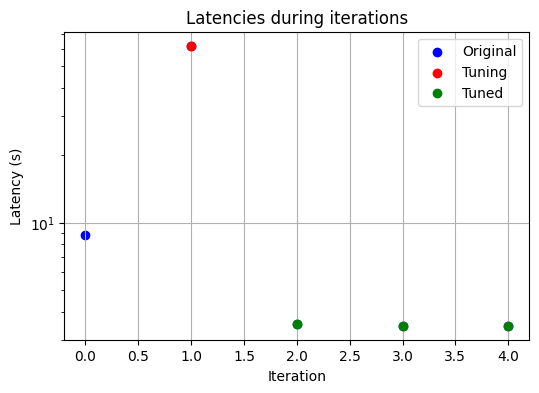

In [ ]:
def batch():
    call_wrapper(audio=[sample_file_path] * 1)
    call_wrapper(audio=[sample_file_path] * max_bs)

visualize_latency(lambda: batch(), iterations=5)

In [9]:
PatchedModule.history

['New top module: EncDecRNNTBPEModel 📊1.1B level=0🪜 state=init⏳ call_count=1',
 'New child module: ConformerEncoder 📊1.1B level=1🪜 state=init⏳ call_count=1',
 'New top module: Linear 📊656.0K level=0🪜 state=init⏳ call_count=1',
 'New top module: Embedding 📊656.0K level=0🪜 state=init⏳ call_count=1',
 'New top module: LSTMDropout 📊6.6M level=0🪜 state=init⏳ call_count=1',
 'New child module: LSTM 📊6.6M level=1🪜 state=init⏳ call_count=1',
 'New top module: Linear 📊410.2K level=0🪜 state=init⏳ call_count=1',
 'New top module: Sequential 📊657.0K level=0🪜 state=init⏳ call_count=1',
 'New child module: Linear 📊657.0K level=1🪜 state=init⏳ call_count=1',
 'No graph breaks in Embedding 📊656.0K. Checking took 0.99s',
 'Tuning Embedding 📊656.0K took 2.34s',
 'Model tuned: Embedding 📊656.0K level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=43',
 'Found graph breaks in LSTMDropout 📊6.6M. Checking took 0.00s',
 'Failed to tune module, unpatched: LSTMDropout 📊6.6M level=0🪜 state=eager⚠️ (graph break) ca

In [10]:
PatchedModule.print_hierarchy()

PatchedModule Hierarchy:
├─ EncDecRNNTBPEModel 📊1.1B level=0🪜 state=eager⚠️ (graph break) call_count=4
  ├─ ConformerEncoder 📊1.1B level=1🪜 state=tuned🎯 (TensorRTBackend) call_count=4
├─ Linear 📊656.0K level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=4
├─ Embedding 📊656.0K level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=43
├─ LSTMDropout 📊6.6M level=0🪜 state=eager⚠️ (graph break) call_count=43
  ├─ LSTM 📊6.6M level=1🪜 state=eager⚠️ (graph break) call_count=43
├─ Linear 📊410.2K level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=43
├─ Sequential 📊657.0K level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=134
  ├─ Linear 📊657.0K level=1🪜 state=detached☑️ call_count=134


# Benchmark

The following benchmark has to be taken with a grain of salt. Seems the bare model is susceptible to high speed variance. It varies from 50 to 90 files/sec.

Second issues is that seems that Linear, Sequential and Embedding layers may slow down the inference, but due to the previous point this has to be confirmed.

The code is left here for the sake of investiation if anyone finds is crucial.

In [ ]:
def benchmark(model, test_files, num_runs=3):
    """Simple timing benchmark."""
    print(f"🔥 Running {num_runs} iterations...")

    def infer(*args, **kwargs):
        # Note: user is controlling batch size in inference and it needs to be passed down to the transcribe function because by default it is 4
        return model.transcribe(
            *args,
            **kwargs,
            override_config=TranscribeConfig(_internal=InternalTranscribeConfig(device=torch.device("cuda"))),
            verbose=False,
        )

    # Warmup
    for _ in range(3):
        infer(**test_files)
        # torch.cuda.empty_cache() # Add cache clearing

    # Time it
    times = []
    for i in range(num_runs):
        start = perf_counter()
        infer(**test_files)
        end = perf_counter()
        times.append(end - start)
        print(f"   Run {i + 1}: {times[-1]:.3f}s")

    avg_time = statistics.mean(times)
    throughput = len(test_files["audio"]) / avg_time

    print(f"   📊 Average: {avg_time:.3f}s ({throughput:.1f} files/sec)")
    return avg_time, throughput

In [12]:
test_files = {"audio": [sample_file_path] * max_bs}
acc_time, acc_throughput = benchmark(pipeline, test_files)

🔥 Running 3 iterations...


Transcribing:   0%|          | 0/16 [00:00<?, ?it/s]

Transcribing: 100%|██████████| 16/16 [00:01<00:00, 11.63it/s]


   Run 1: 1.394s


Transcribing: 100%|██████████| 16/16 [00:01<00:00, 11.56it/s]


   Run 2: 1.404s


Transcribing: 100%|██████████| 16/16 [00:01<00:00, 11.54it/s]

   Run 3: 1.406s
   📊 Average: 1.401s (45.7 files/sec)


In [14]:
pipeline = get_bare_model()
orig_time, orig_throughput = benchmark(pipeline, test_files)

[NeMo I 2025-08-08 13:06:54 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2025-08-08 13:06:54 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /disk1/NVIDIA/datasets/LibriSpeech_NeMo/librivox-train-all.json
    sample_rate: 16000
    batch_size: 16
    shuffle: true
    num_workers: 8
    pin_memory: true
    use_start_end_token: false
    trim_silence: false
    max_duration: 16.7
    min_duration: 0.1
    is_tarred: false
    tarred_audio_filepaths: null
    shuffle_n: 2048
    bucketing_strategy: fully_randomized
    bucketing_batch_size: null
    
[NeMo W 2025-08-08 13:06:54 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath: /disk1/NVIDIA/datasets

[NeMo I 2025-08-08 13:06:54 nemo_logging:393] PADDING: 0
[NeMo I 2025-08-08 13:06:57 nemo_logging:393] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}
[NeMo I 2025-08-08 13:06:57 nemo_logging:393] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}


[NeMo W 2025-08-08 13:06:57 nemo_logging:405] No conditional node support for Cuda.
    Cuda graphs with while loops are disabled, decoding speed will be slower
    Reason: No `cuda-python` module. Please do `pip install cuda-python>=12.3`


[NeMo I 2025-08-08 13:06:57 nemo_logging:393] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0}


...

   Run 1: 1.266s


Transcribing: 100%|██████████| 16/16 [00:01<00:00, 12.97it/s]


   Run 2: 1.251s


Transcribing: 100%|██████████| 16/16 [00:01<00:00, 12.76it/s]

   Run 3: 1.270s
   📊 Average: 1.262s (50.7 files/sec)


In [15]:
speedup = orig_time / acc_time
improvement = ((acc_throughput - orig_throughput) / orig_throughput) * 100


In [16]:

print("\n" + "=" * 60)
print("🏁 FINAL RESULTS")
print("=" * 60)
print(f"🔧 Original:    {orig_time:.3f}s ({orig_throughput:.1f} files/sec)")
print(f"⚡ Accelerated: {acc_time:.3f}s ({acc_throughput:.1f} files/sec)")
print(f"🚀 Speedup:     {speedup:.2f}x ({improvement:+.1f}%)")



🏁 FINAL RESULTS
🔧 Original:    1.262s (50.7 files/sec)
⚡ Accelerated: 1.401s (45.7 files/sec)
🚀 Speedup:     0.90x (-9.9%)
